# Code RAG Exploration on `data/kdk`

This notebook explores how to build a RAG pipeline over the KDK codebase under `data/kdk`.

The goal is not to answer documentation questions, but to retrieve the right source files and code regions for implementation questions such as:

- Where is a given service helper implemented?
- Which file defines a given composable or utility?
- Which source file is responsible for a given behavior?

The notebook is organized as an engineering investigation:

1. Inspect the code corpus and decide what should enter a code RAG index
2. Implement two chunking strategies for code
3. Ingest both into Qdrant with the same embedding model
4. Evaluate retrieval on a small, explicit code benchmark with known target files
5. Summarize what works, what fails, and what to build next


In [1]:
import json
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, PointStruct, VectorParams

sns.set_theme(style="whitegrid", palette="muted")
matplotlib.rcParams["figure.dpi"] = 120
print("Imports OK")


Imports OK


In [2]:
ROOT_DIR = Path("..").resolve()
DATA_DIR = ROOT_DIR / "data" / "kdk"
OUTPUT_DIR = ROOT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

QDRANT_URL = "http://localhost:6333"
OLLAMA_URL = "http://localhost:11434"
EMBEDDING_MODEL = "nomic-embed-text"

FILE_COLLECTION = "nb05_code_file_recursive"
SYMBOL_COLLECTION = "nb05_code_symbol_aware"
RESET_ARTIFACTS = True

SUPPORTED_CODE_EXTS = {".js", ".vue", ".mjs", ".cjs"}
DEFAULT_INCLUDE_DIRS = [
    "core",
    "map",
]
EXCLUDE_PARTS = {
    "docs",
    "node_modules",
    ".git",
    "__screenshots__",
}

FILE_CHUNK_SIZE = 1400
FILE_CHUNK_OVERLAP = 150
SYMBOL_CHUNK_SIZE = 1200
SYMBOL_CHUNK_OVERLAP = 120
MIN_SYMBOL_CHARS = 120
TOP_K = 10

CHUNK_STATS_PATH = OUTPUT_DIR / "nb05_code_chunk_stats.csv"
RETRIEVAL_EVAL_PATH = OUTPUT_DIR / "nb05_code_retrieval_eval.json"

print(f"Data dir: {DATA_DIR} (exists={DATA_DIR.exists()})")
print(f"Embedding model: {EMBEDDING_MODEL}")
print(f"Qdrant: {QDRANT_URL}")
print(f"Reset artifacts: {RESET_ARTIFACTS}")


Data dir: D:\kalisio\code_rag\data\kdk (exists=True)
Embedding model: nomic-embed-text
Qdrant: http://localhost:6333
Reset artifacts: True


In [3]:
def should_include_file(path: Path) -> bool:
    if path.suffix.lower() not in SUPPORTED_CODE_EXTS:
        return False
    parts = set(path.parts)
    if parts & EXCLUDE_PARTS:
        return False
    rel = path.relative_to(DATA_DIR)
    return rel.parts[0] in DEFAULT_INCLUDE_DIRS or rel.parent == Path('.')


all_files = [p for p in DATA_DIR.rglob('*') if p.is_file()]
code_files = [p for p in all_files if should_include_file(p)]

ext_counts = Counter(p.suffix.lower() or '<no_ext>' for p in all_files)
code_ext_counts = Counter(p.suffix.lower() for p in code_files)
top_level_counts = Counter(p.relative_to(DATA_DIR).parts[0] for p in code_files)

print(f"All files in repo snapshot: {len(all_files)}")
print(f"Code files selected for RAG: {len(code_files)}")
print("Top extensions in full snapshot:")
for ext, count in ext_counts.most_common(10):
    print(f"  {ext}: {count}")
print("\nSelected code file extensions:")
for ext, count in code_ext_counts.most_common():
    print(f"  {ext}: {count}")
print("\nSelected top-level folders:")
for name, count in top_level_counts.most_common():
    print(f"  {name}: {count}")


All files in repo snapshot: 971
Code files selected for RAG: 544
Top extensions in full snapshot:
  .js: 362
  .vue: 242
  .md: 142
  .png: 71
  .svg: 40
  .json: 26
  .mjs: 18
  .xml: 16
  .ejs: 9
  <no_ext>: 8

Selected code file extensions:
  .js: 303
  .vue: 237
  .cjs: 4

Selected top-level folders:
  core: 299
  map: 232
  client.globe.js: 1
  client.js: 1
  client.map.js: 1
  core.api.js: 1
  core.client.js: 1
  core.common.js: 1
  map.api.js: 1
  map.client.globe.js: 1
  map.client.js: 1
  map.client.map.js: 1
  map.common.js: 1
  map.config.cjs: 1
  test.api.js: 1


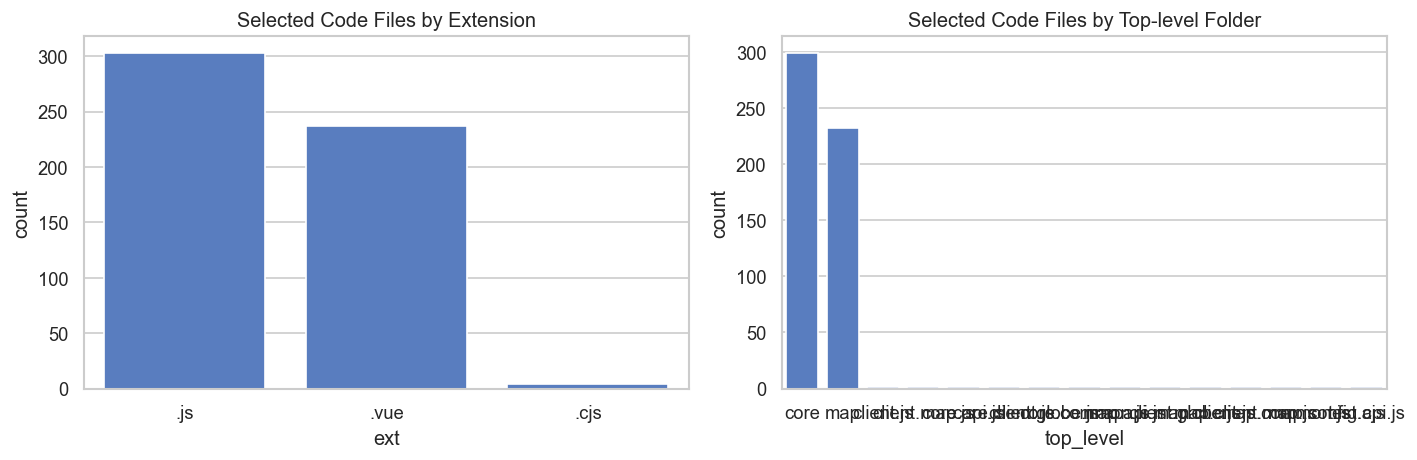

,source,ext,top_level,size_bytes
125,map\client\mixins\map\mixin.base-map.js,.js,map,42075
117,map\client\mixins\globe\mixin.base-globe.js,.js,map,39011
119,map\client\mixins\globe\mixin.geojson-layers.js,.js,map,37899
129,map\client\mixins\map\mixin.geojson-layers.js,.js,map,36459
127,map\client\mixins\map\mixin.edit-layers.js,.js,map,27421
108,map\client\utils\utils.layers.js,.js,map,26873
106,map\client\utils\utils.features.js,.js,map,24653
245,core\api\application.js,.js,core,24587
90,map\client\mixins\mixin.activity.js,.js,map,24369
65,map\client\components\KMeasureTool.vue,.vue,map,24233


In [4]:
inventory_df = pd.DataFrame([
    {
        "source": str(p.relative_to(DATA_DIR)),
        "ext": p.suffix.lower(),
        "top_level": p.relative_to(DATA_DIR).parts[0],
        "size_bytes": p.stat().st_size,
    }
    for p in code_files
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=inventory_df.groupby('ext').size().reset_index(name='count').sort_values('count', ascending=False), x='ext', y='count', ax=axes[0])
axes[0].set_title('Selected Code Files by Extension')
sns.barplot(data=inventory_df.groupby('top_level').size().reset_index(name='count').sort_values('count', ascending=False), x='top_level', y='count', ax=axes[1])
axes[1].set_title('Selected Code Files by Top-level Folder')
plt.tight_layout()
plt.show()

inventory_df.sort_values('size_bytes', ascending=False).head(10)


## Strategy Design

We compare two code chunking strategies:

- `file_recursive`: treat each source file as a document, then split recursively by lines and spaces
- `symbol_aware`: split code around exported functions, classes, top-level declarations, and Vue `<script>` blocks, then recursively split oversized symbols

The expectation is that `symbol_aware` should improve retrieval for implementation questions because many code questions target a function, class, or exported helper rather than a whole file.


In [5]:
file_splitter = RecursiveCharacterTextSplitter(
    chunk_size=FILE_CHUNK_SIZE,
    chunk_overlap=FILE_CHUNK_OVERLAP,
    separators=["\n\n", "\n", " "],
)

symbol_splitter = RecursiveCharacterTextSplitter(
    chunk_size=SYMBOL_CHUNK_SIZE,
    chunk_overlap=SYMBOL_CHUNK_OVERLAP,
    separators=["\n\n", "\n", " "],
)

SYMBOL_PATTERN = re.compile(
    r"(?m)^(export\s+default\s+async\s+function\s+\w+.*$|"
    r"export\s+default\s+function\s+\w+.*$|"
    r"export\s+async\s+function\s+\w+.*$|"
    r"export\s+function\s+\w+.*$|"
    r"export\s+class\s+\w+.*$|"
    r"export\s+const\s+\w+.*$|"
    r"export\s+let\s+\w+.*$|"
    r"export\s+var\s+\w+.*$|"
    r"async\s+function\s+\w+.*$|"
    r"function\s+\w+.*$|"
    r"class\s+\w+.*$)"
)


def read_code_file(path: Path) -> str:
    return path.read_text(encoding='utf-8', errors='ignore')


def extract_vue_blocks(text: str) -> dict:
    blocks = {}
    for tag in ['template', 'script', 'style']:
        pattern = re.compile(rf'<{tag}[^>]*>(.*?)</{tag}>', re.DOTALL)
        matches = pattern.findall(text)
        if matches:
            blocks[tag] = '\n\n'.join(match.strip() for match in matches if match.strip())
    return blocks


def detect_symbol_name(header_line: str) -> str:
    patterns = [
        r'export\s+default\s+async\s+function\s+(\w+)',
        r'export\s+default\s+function\s+(\w+)',
        r'export\s+async\s+function\s+(\w+)',
        r'export\s+function\s+(\w+)',
        r'export\s+class\s+(\w+)',
        r'export\s+const\s+(\w+)',
        r'export\s+let\s+(\w+)',
        r'function\s+(\w+)',
        r'class\s+(\w+)',
    ]
    for pattern in patterns:
        match = re.search(pattern, header_line)
        if match:
            return match.group(1)
    return 'module_block'


def make_metadata(path: Path, kind: str, symbol: str | None = None, block: str | None = None) -> dict:
    rel = str(path.relative_to(DATA_DIR))
    return {
        'source': rel,
        'ext': path.suffix.lower(),
        'top_level': path.relative_to(DATA_DIR).parts[0],
        'chunk_kind': kind,
        'symbol': symbol or '',
        'block': block or '',
    }


def chunk_file_recursive(path: Path) -> list[dict]:
    text = read_code_file(path).strip()
    if not text:
        return []
    docs = file_splitter.create_documents([text], metadatas=[make_metadata(path, 'file')])
    return [{'text': doc.page_content.strip(), 'metadata': dict(doc.metadata)} for doc in docs if doc.page_content.strip()]


def split_js_symbols(text: str) -> list[tuple[str, str]]:
    matches = list(SYMBOL_PATTERN.finditer(text))
    if not matches:
        return [('module_block', text.strip())] if text.strip() else []
    chunks = []
    if matches[0].start() > 0:
        preamble = text[:matches[0].start()].strip()
        if preamble:
            chunks.append(('module_preamble', preamble))
    for i, match in enumerate(matches):
        start = match.start()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        block = text[start:end].strip()
        if not block:
            continue
        header = match.group(0).strip()
        chunks.append((detect_symbol_name(header), block))
    return chunks


def chunk_symbol_aware(path: Path) -> list[dict]:
    text = read_code_file(path)
    results = []
    if path.suffix.lower() == '.vue':
        blocks = extract_vue_blocks(text)
        script_text = blocks.get('script', '').strip()
        template_text = blocks.get('template', '').strip()
        if script_text:
            for symbol_name, symbol_text in split_js_symbols(script_text):
                if len(symbol_text.strip()) < MIN_SYMBOL_CHARS:
                    continue
                docs = symbol_splitter.create_documents([symbol_text], metadatas=[make_metadata(path, 'vue_script_symbol', symbol=symbol_name, block='script')])
                results.extend({'text': doc.page_content.strip(), 'metadata': dict(doc.metadata)} for doc in docs if doc.page_content.strip())
        if template_text and len(template_text) >= MIN_SYMBOL_CHARS:
            docs = symbol_splitter.create_documents([template_text], metadatas=[make_metadata(path, 'vue_template', block='template')])
            results.extend({'text': doc.page_content.strip(), 'metadata': dict(doc.metadata)} for doc in docs if doc.page_content.strip())
    else:
        for symbol_name, symbol_text in split_js_symbols(text):
            if len(symbol_text.strip()) < MIN_SYMBOL_CHARS:
                continue
            docs = symbol_splitter.create_documents([symbol_text], metadatas=[make_metadata(path, 'symbol', symbol=symbol_name)])
            results.extend({'text': doc.page_content.strip(), 'metadata': dict(doc.metadata)} for doc in docs if doc.page_content.strip())
    return results


file_chunks = []
symbol_chunks = []
for path in tqdm(code_files, desc='Chunking code files'):
    file_chunks.extend(chunk_file_recursive(path))
    symbol_chunks.extend(chunk_symbol_aware(path))

print(f'file_recursive chunks: {len(file_chunks)}')
print(f'symbol_aware chunks: {len(symbol_chunks)}')


Chunking code files:   0%|          | 0/544 [00:00<?, ?it/s]

file_recursive chunks: 2241
symbol_aware chunks: 3032


In [6]:
def code_chunk_stats(chunks: list[dict], strategy: str) -> pd.DataFrame:
    rows = []
    for chunk in chunks:
        text = chunk['text']
        meta = chunk['metadata']
        rows.append({
            'strategy': strategy,
            'source': meta.get('source', ''),
            'ext': meta.get('ext', ''),
            'top_level': meta.get('top_level', ''),
            'chunk_kind': meta.get('chunk_kind', ''),
            'symbol': meta.get('symbol', ''),
            'block': meta.get('block', ''),
            'length': len(text),
            'line_count': len([line for line in text.splitlines() if line.strip()]),
            'preview': text[:200].replace('\n', ' '),
        })
    return pd.DataFrame(rows)


chunk_df = pd.concat([
    code_chunk_stats(file_chunks, 'file_recursive'),
    code_chunk_stats(symbol_chunks, 'symbol_aware'),
], ignore_index=True)
chunk_df.drop(columns=['preview']).to_csv(CHUNK_STATS_PATH, index=False, encoding='utf-8-sig')

chunk_summary = chunk_df.groupby('strategy').agg(
    total_chunks=('length', 'size'),
    mean_length=('length', 'mean'),
    median_length=('length', 'median'),
    max_length=('length', 'max'),
    min_length=('length', 'min'),
    unique_sources=('source', 'nunique'),
    unique_symbols=('symbol', lambda s: (s != '').sum()),
).round(2)
chunk_summary


,total_chunks,mean_length,median_length,max_length,min_length,unique_sources,unique_symbols
strategy,,,,,,,
file_recursive,2241,982.94,1149.0,1406,1,544,0
symbol_aware,3032,688.98,679.5,1406,1,525,2744


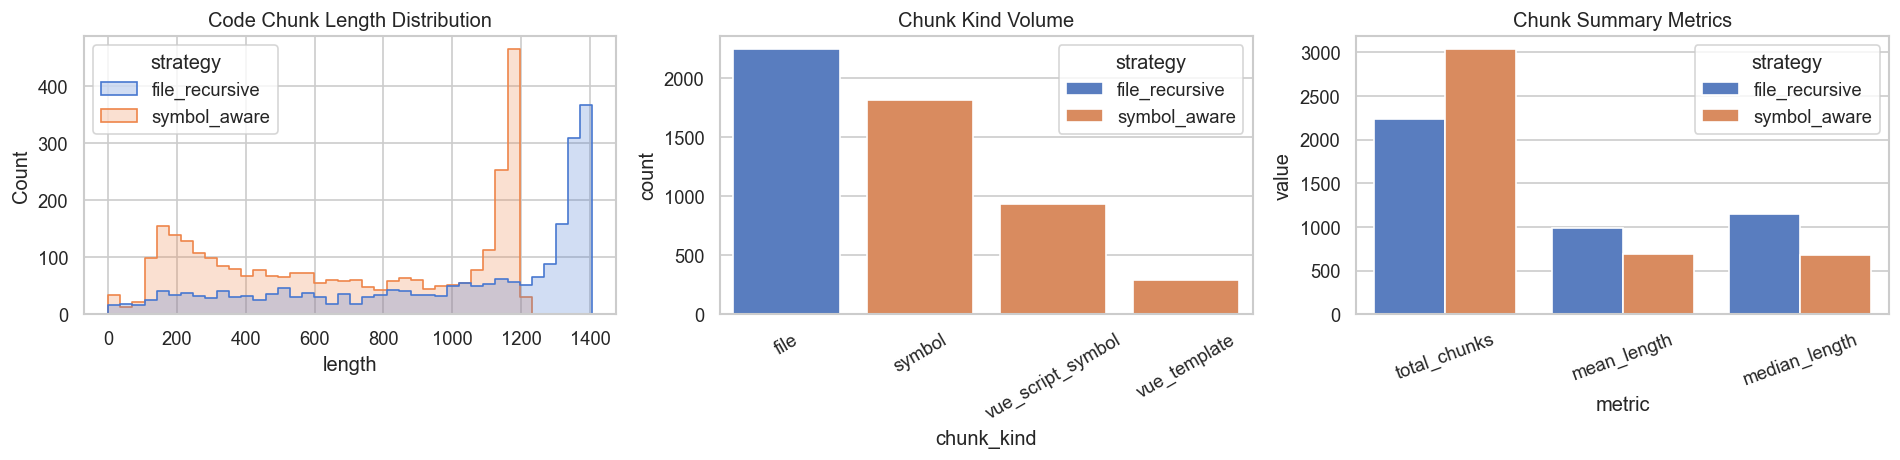

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(data=chunk_df, x='length', hue='strategy', bins=40, ax=axes[0], element='step', stat='count', common_norm=False)
axes[0].set_title('Code Chunk Length Distribution')
sns.barplot(data=chunk_df.groupby(['strategy', 'chunk_kind']).size().reset_index(name='count'), x='chunk_kind', y='count', hue='strategy', ax=axes[1])
axes[1].set_title('Chunk Kind Volume')
axes[1].tick_params(axis='x', rotation=30)
sns.barplot(data=chunk_summary.reset_index()[['strategy', 'total_chunks', 'mean_length', 'median_length']].melt(id_vars='strategy', var_name='metric', value_name='value'), x='metric', y='value', hue='strategy', ax=axes[2])
axes[2].set_title('Chunk Summary Metrics')
axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## Retrieval Benchmark

For code RAG, evaluation needs known target files or symbols. We define a small benchmark of explicit implementation questions whose ground-truth file paths are already known from manual inspection.

This is intentionally narrow and pragmatic: the goal is to check whether a chunking strategy helps retrieve the right code location, not to build a full benchmark yet.


In [8]:
benchmark = [
    {
        'question_id': 1,
        'question': 'Where is createService implemented on the client API?',
        'targets': ['core/client/api.js'],
    },
    {
        'question_id': 2,
        'question': 'Which file defines createOfflineService for client-side offline services?',
        'targets': ['core/client/api.js'],
    },
    {
        'question_id': 3,
        'question': 'Where is getServicePath implemented?',
        'targets': ['core/client/api.js'],
    },
    {
        'question_id': 4,
        'question': 'Which file defines the map defineUserAbilities helper?',
        'targets': ['map/common/permissions.js'],
    },
    {
        'question_id': 5,
        'question': 'Where is the useWeather composable implemented?',
        'targets': ['map/client/composables/weather.js'],
    },
    {
        'question_id': 6,
        'question': 'Which file defines addQueryParameter and URL-building utilities?',
        'targets': ['core/common/utils.js'],
    },
    {
        'question_id': 7,
        'question': 'Where is makeDiacriticPattern implemented?',
        'targets': ['core/common/utils.js'],
    },
    {
        'question_id': 8,
        'question': 'Which file defines the GeoTiffGridSource class?',
        'targets': ['map/common/geotiff-grid-source.js'],
    },
    {
        'question_id': 9,
        'question': 'Where are PMTiles layers and related schema helpers implemented?',
        'targets': ['map/common/pmtiles-utils.js'],
    },
    {
        'question_id': 10,
        'question': 'Which file implements the useHighlight composable?',
        'targets': ['map/client/composables/highlight.js'],
    },
]

benchmark_df = pd.DataFrame(benchmark)
benchmark_df


,question_id,question,targets
0,1,Where is createService implemented on the clie...,[core/client/api.js]
1,2,Which file defines createOfflineService for cl...,[core/client/api.js]
2,3,Where is getServicePath implemented?,[core/client/api.js]
3,4,Which file defines the map defineUserAbilities...,[map/common/permissions.js]
4,5,Where is the useWeather composable implemented?,[map/client/composables/weather.js]
5,6,Which file defines addQueryParameter and URL-b...,[core/common/utils.js]
6,7,Where is makeDiacriticPattern implemented?,[core/common/utils.js]
7,8,Which file defines the GeoTiffGridSource class?,[map/common/geotiff-grid-source.js]
8,9,Where are PMTiles layers and related schema he...,[map/common/pmtiles-utils.js]
9,10,Which file implements the useHighlight composa...,[map/client/composables/highlight.js]


In [9]:
embeddings = OllamaEmbeddings(model=EMBEDDING_MODEL, base_url=OLLAMA_URL)
qdrant = QdrantClient(url=QDRANT_URL)


def reset_nb05_artifacts() -> None:
    for collection in [FILE_COLLECTION, SYMBOL_COLLECTION]:
        if qdrant.collection_exists(collection):
            qdrant.delete_collection(collection)
            print(f'Deleted collection: {collection}')
    if RETRIEVAL_EVAL_PATH.exists():
        RETRIEVAL_EVAL_PATH.unlink()
        print(f'Removed cache file: {RETRIEVAL_EVAL_PATH.name}')


def embed_chunks(chunks: list[dict], batch_size: int = 32) -> np.ndarray:
    vectors = []
    texts = [chunk['text'] for chunk in chunks]
    for start in tqdm(range(0, len(texts), batch_size), desc='Embedding code chunks'):
        batch = texts[start:start + batch_size]
        vectors.extend(embeddings.embed_documents(batch))
    return np.array(vectors)


def ingest(collection_name: str, chunks: list[dict]) -> None:
    vectors = embed_chunks(chunks)
    if qdrant.collection_exists(collection_name):
        qdrant.delete_collection(collection_name)
    qdrant.create_collection(
        collection_name=collection_name,
        vectors_config=VectorParams(size=vectors.shape[1], distance=Distance.COSINE),
    )
    points = [
        PointStruct(
            id=i,
            vector=vectors[i].tolist(),
            payload={**chunks[i]['metadata'], 'text': chunks[i]['text']},
        )
        for i in range(len(chunks))
    ]
    qdrant.upsert(collection_name=collection_name, points=points)
    info = qdrant.get_collection(collection_name)
    print(f'{collection_name}: {info.points_count} points')


if RESET_ARTIFACTS:
    reset_nb05_artifacts()

ingest(FILE_COLLECTION, file_chunks)
ingest(SYMBOL_COLLECTION, symbol_chunks)


Embedding code chunks:   0%|          | 0/71 [00:00<?, ?it/s]

nb05_code_file_recursive: 2241 points


Embedding code chunks:   0%|          | 0/95 [00:00<?, ?it/s]

nb05_code_symbol_aware: 3032 points


In [10]:
def retrieve(question: str, collection_name: str, k: int = TOP_K):
    qvec = embeddings.embed_query(question)
    return qdrant.query_points(
        collection_name=collection_name,
        query=qvec,
        limit=k,
        with_payload=True,
    ).points


def normalize_repo_path(path: str) -> str:
    return path.replace('\\', '/').strip()


def first_target_rank(points, targets: list[str]) -> int | None:
    normalized_targets = {normalize_repo_path(target) for target in targets}
    for rank, point in enumerate(points, start=1):
        source = normalize_repo_path((point.payload or {}).get('source', ''))
        if source in normalized_targets:
            return rank
    return None


def retrieval_rows(collection_name: str, strategy: str) -> list[dict]:
    rows = []
    for item in benchmark:
        t0 = time.time()
        points = retrieve(item['question'], collection_name, TOP_K)
        elapsed = time.time() - t0
        rank = first_target_rank(points, item['targets'])
        rows.append({
            'question_id': item['question_id'],
            'question': item['question'],
            'targets': item['targets'],
            'strategy': strategy,
            'first_target_rank': rank,
            'hit_at_1': rank == 1,
            'hit_at_3': (rank is not None and rank <= 3),
            'hit_at_5': (rank is not None and rank <= 5),
            'hit_at_10': (rank is not None and rank <= 10),
            'reciprocal_rank': 1 / rank if rank is not None else 0.0,
            'retrieval_time': elapsed,
            'retrieved_sources': [(p.payload or {}).get('source', '') for p in points],
            'retrieved_symbols': [(p.payload or {}).get('symbol', '') for p in points],
            'retrieved_kinds': [(p.payload or {}).get('chunk_kind', '') for p in points],
        })
    return rows


if RETRIEVAL_EVAL_PATH.exists() and not RESET_ARTIFACTS:
    retrieval_eval = json.loads(RETRIEVAL_EVAL_PATH.read_text(encoding='utf-8'))
else:
    retrieval_eval = retrieval_rows(FILE_COLLECTION, 'file_recursive') + retrieval_rows(SYMBOL_COLLECTION, 'symbol_aware')
    RETRIEVAL_EVAL_PATH.write_text(json.dumps(retrieval_eval, ensure_ascii=False, indent=2), encoding='utf-8')

eval_df = pd.DataFrame(retrieval_eval)
eval_df['rank_for_metrics'] = eval_df['first_target_rank'].fillna(TOP_K + 1)
eval_df


,question_id,question,targets,strategy,first_target_rank,hit_at_1,hit_at_3,hit_at_5,hit_at_10,reciprocal_rank,retrieval_time,retrieved_sources,retrieved_symbols,retrieved_kinds,rank_for_metrics
0,1,Where is createService implemented on the clie...,[core/client/api.js],file_recursive,None,False,False,False,False,0.0,0.261883,"[map\client\utils\utils.capture.js, map\client...","[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11
1,2,Which file defines createOfflineService for cl...,[core/client/api.js],file_recursive,None,False,False,False,False,0.0,0.066591,"[core\client\api.js, map\client\utils\utils.ca...","[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11
2,3,Where is getServicePath implemented?,[core/client/api.js],file_recursive,None,False,False,False,False,0.0,0.072414,"[map\client\utils\utils.capture.js, map\api\se...","[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11
3,4,Which file defines the map defineUserAbilities...,[map/common/permissions.js],file_recursive,None,False,False,False,False,0.0,0.069105,[map\client\components\location\KLocationMap.v...,"[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11
4,5,Where is the useWeather composable implemented?,[map/client/composables/weather.js],file_recursive,None,False,False,False,False,0.0,0.099689,"[map\client\utils\utils.capture.js, map\client...","[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11
5,6,Which file defines addQueryParameter and URL-b...,[core/common/utils.js],file_recursive,None,False,False,False,False,0.0,0.082100,[map\api\services\features\features.service.js...,"[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11
6,7,Where is makeDiacriticPattern implemented?,[core/common/utils.js],file_recursive,None,False,False,False,False,0.0,0.083825,"[map\client\utils\utils.capture.js, map\api\se...","[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11
7,8,Which file defines the GeoTiffGridSource class?,[map/common/geotiff-grid-source.js],file_recursive,None,False,False,False,False,0.0,0.075164,"[map\client\utils\utils.capture.js, core\commo...","[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11
8,9,Where are PMTiles layers and related schema he...,[map/common/pmtiles-utils.js],file_recursive,None,False,False,False,False,0.0,0.064787,"[map\client\mixins\map\mixin.edit-layers.js, m...","[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11
9,10,Which file implements the useHighlight composa...,[map/client/composables/highlight.js],file_recursive,None,False,False,False,False,0.0,0.069177,"[map\client\utils\utils.capture.js, map\api\se...","[, , , , , , , , , ]","[file, file, file, file, file, file, file, fil...",11


In [11]:
metrics = eval_df.groupby('strategy').agg(
    hit_at_1=('hit_at_1', 'mean'),
    hit_at_3=('hit_at_3', 'mean'),
    hit_at_5=('hit_at_5', 'mean'),
    hit_at_10=('hit_at_10', 'mean'),
    mean_first_target_rank=('rank_for_metrics', 'mean'),
    median_first_target_rank=('rank_for_metrics', 'median'),
    mrr=('reciprocal_rank', 'mean'),
    mean_retrieval_time=('retrieval_time', 'mean'),
).round(3)
metrics


,hit_at_1,hit_at_3,hit_at_5,hit_at_10,mean_first_target_rank,median_first_target_rank,mrr,mean_retrieval_time
strategy,,,,,,,,
file_recursive,0.0,0.0,0.0,0.0,11.0,11.0,0.0,0.094
symbol_aware,0.0,0.0,0.0,0.0,11.0,11.0,0.0,0.081


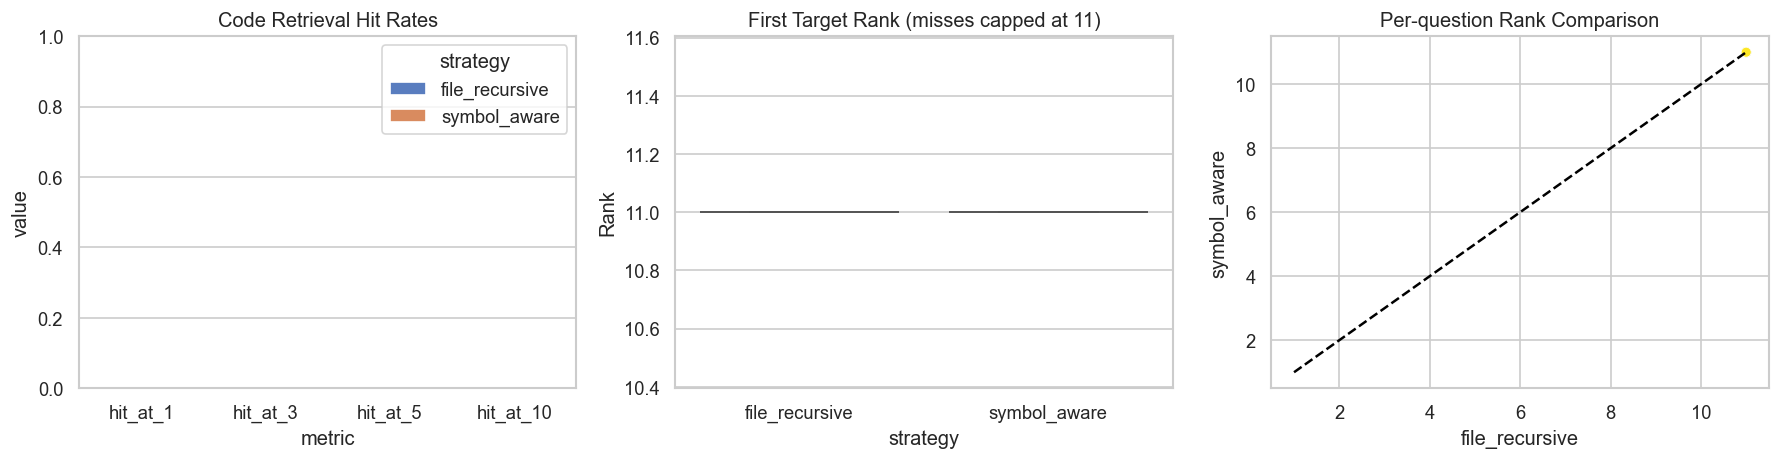

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_hits = metrics.reset_index()[['strategy', 'hit_at_1', 'hit_at_3', 'hit_at_5', 'hit_at_10']].melt(id_vars='strategy', var_name='metric', value_name='value')
sns.barplot(data=plot_hits, x='metric', y='value', hue='strategy', ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title('Code Retrieval Hit Rates')
sns.boxplot(data=eval_df, x='strategy', y='rank_for_metrics', ax=axes[1])
axes[1].set_title('First Target Rank (misses capped at 11)')
axes[1].set_ylabel('Rank')
rank_pivot = eval_df.pivot(index='question_id', columns='strategy', values='rank_for_metrics').reset_index()
sns.scatterplot(data=rank_pivot, x='file_recursive', y='symbol_aware', hue='question_id', palette='viridis', legend=False, ax=axes[2])
axes[2].plot([1, TOP_K + 1], [1, TOP_K + 1], linestyle='--', color='black')
axes[2].set_title('Per-question Rank Comparison')
axes[2].set_xlabel('file_recursive')
axes[2].set_ylabel('symbol_aware')
plt.tight_layout()
plt.show()


In [13]:
comparison_df = eval_df.pivot(index='question_id', columns='strategy', values='rank_for_metrics').reset_index()
comparison_df['delta'] = comparison_df['file_recursive'] - comparison_df['symbol_aware']
comparison_df = comparison_df.merge(benchmark_df[['question_id', 'question']], on='question_id', how='left')
comparison_df.sort_values('delta', ascending=False)


,question_id,file_recursive,symbol_aware,delta,question
0,1,11,11,0,Where is createService implemented on the clie...
1,2,11,11,0,Which file defines createOfflineService for cl...
2,3,11,11,0,Where is getServicePath implemented?
3,4,11,11,0,Which file defines the map defineUserAbilities...
4,5,11,11,0,Where is the useWeather composable implemented?
5,6,11,11,0,Which file defines addQueryParameter and URL-b...
6,7,11,11,0,Where is makeDiacriticPattern implemented?
7,8,11,11,0,Which file defines the GeoTiffGridSource class?
8,9,11,11,0,Where are PMTiles layers and related schema he...
9,10,11,11,0,Which file implements the useHighlight composa...


In [14]:
inspect_ids = [1, 4, 5, 8, 9]
rows = []
for item in benchmark:
    if item['question_id'] not in inspect_ids:
        continue
    for strategy, collection in [('file_recursive', FILE_COLLECTION), ('symbol_aware', SYMBOL_COLLECTION)]:
        points = retrieve(item['question'], collection, TOP_K)
        for rank, point in enumerate(points[:5], start=1):
            payload = point.payload or {}
            rows.append({
                'question_id': item['question_id'],
                'strategy': strategy,
                'rank': rank,
                'source': payload.get('source', ''),
                'symbol': payload.get('symbol', ''),
                'chunk_kind': payload.get('chunk_kind', ''),
                'preview': payload.get('text', '')[:180].replace('\n', ' '),
            })
inspection_df = pd.DataFrame(rows)
inspection_df


,question_id,strategy,rank,source,symbol,chunk_kind,preview
0,1,file_recursive,1,map\client\utils\utils.capture.js,,file,basePdf:
1,1,file_recursive,2,map\client\mixins\globe\mixin.geojson-layers.js,,file,"}, async updateLayer (name, geoJson, updat..."
2,1,file_recursive,3,map\client\geocoder.js,,file,}
3,1,file_recursive,4,map\client\components\widget\KTimeSeriesToolba...,,file,/* TODO: action previously available on KTimeS...
4,1,file_recursive,5,map\api\services\features\features.service.js,,file,"}, properties: { ..."
5,1,symbol_aware,1,map\client\utils\utils.capture.js,generatePdf,symbol,basePdf:
6,1,symbol_aware,2,core\client\utils\index.js,module_preamble,symbol,/** * This function allow you to modify a JS ...
7,1,symbol_aware,3,map\client\geocoder.js,Geocoder,symbol,}
8,1,symbol_aware,4,map\client\components\catalog\KConnectLayer.vue,onConnect,vue_script_symbol,} } else if (service.value.protocol === 'WMS...
9,1,symbol_aware,5,core\client\components\form\KIconField.vue,module_block,vue_script_symbol,"}, onIconChoosed (icon) { // We supp..."


## What This Validates

This notebook validates a first-pass code RAG design, not a final production pipeline.

Key questions answered here:

- Which parts of `data/kdk` are useful as a code corpus?
- Does symbol-aware chunking help retrieve the right implementation file faster than file-level chunking?
- Which benchmark questions still fail, and do they fail because of chunking, embeddings, or benchmark design?

Likely next steps after this notebook:

1. Add import graph and path metadata into chunks
2. Distinguish runtime source code from tests and demo code more explicitly
3. Add hybrid retrieval or reranking for symbol names and path-like queries
4. Expand the benchmark from file-level targets to symbol-level targets
